In [1]:
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt

G = nx.Graph() # Creates an undirected graph

L0_nodes = ["L0_1","L0_2","L0_3"]
L1_nodes = ["L1_1","L1_2"]
L2_nodes = ["L2_1","L2_2","L2_3"]
L3_nodes = ["L3_1","L3_2"]

direction = {
    "L0_1": +1, "L0_2": +1, "L0_3": -1,
}
puc_value = {
    "L0_1": 1.00, "L0_2": 1.00, "L0_3": 1.00,
}

G.add_nodes_from(L0_nodes)
G.add_nodes_from(L1_nodes)
G.add_nodes_from(L2_nodes)
G.add_nodes_from(L3_nodes)

nx.set_node_attributes(G, direction, "direction")
nx.set_node_attributes(G, puc_value, "puc_value")


cross_edges = {
    ("L0_1", "L1_1"): +1,
    ("L0_1", "L1_2"): -1,
    ("L0_2", "L1_1"): -1,
    ("L0_2", "L1_2"): -1,
    ("L0_3", "L1_1"): -1,
    ("L0_3", "L1_2"): -1,
    ("L1_1", "L1_2"): +1,
    ("L1_1", "L2_1"): +1,
    ("L1_1", "L2_2"): +1,
    ("L1_2", "L2_2"): +1,
    ("L1_2", "L2_3"): +1,
    ("L2_1", "L2_3"): -1,
    ("L2_1", "L3_1"): +1,
    ("L2_1", "L3_2"): -1,
    ("L2_2", "L3_1"): -1,
    ("L2_3", "L3_1"): +1,
    ("L2_3", "L3_2"): +1,
}

for (u, v), rel in cross_edges.items():
    G.add_edge(u, v, relation=rel)


for n in G.nodes:
    print(n, G.nodes[n].get("direction"), G.nodes[n].get("puc_value"))
print("\n")
for u, v in G.edges:
    print(u, v, G[u][v]["relation"])


L0_1 1 1.0
L0_2 1 1.0
L0_3 -1 1.0
L1_1 None None
L1_2 None None
L2_1 None None
L2_2 None None
L2_3 None None
L3_1 None None
L3_2 None None


L0_1 L1_1 1
L0_1 L1_2 -1
L0_2 L1_1 -1
L0_2 L1_2 -1
L0_3 L1_1 -1
L0_3 L1_2 -1
L1_1 L1_2 1
L1_1 L2_1 1
L1_1 L2_2 1
L1_2 L2_2 1
L1_2 L2_3 1
L2_1 L2_3 -1
L2_1 L3_1 1
L2_1 L3_2 -1
L2_2 L3_1 -1
L2_3 L3_1 1
L2_3 L3_2 1


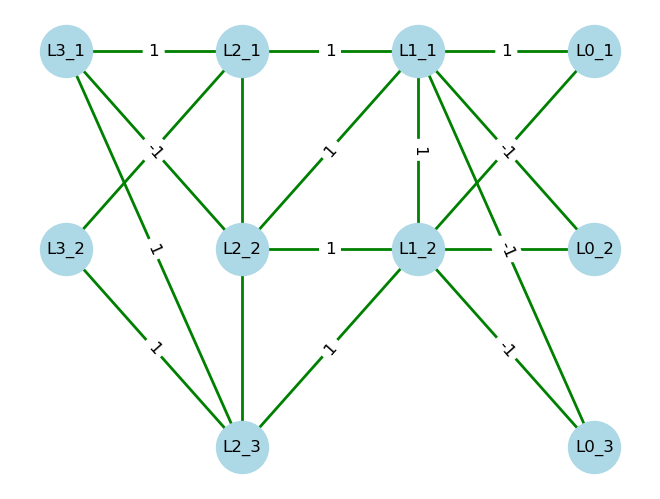

In [2]:
# Let source be b nodes
sources = []
for n in G.nodes:
    if n.startswith("L0"):
        sources.append(n)

# Compute distances manually
distances = {}
for s in sources:
    single_dist = nx.single_source_shortest_path_length(G, s)
    for node, d in single_dist.items():
        if (node not in distances) or (d < distances[node]):
            distances[node] = d
            # calculate all edge properties for node n and n-1

# Group nodes by layers
layers = defaultdict(list)
for node, d in distances.items():
    layers[d].append(node)


# Position nodes for plotting
pos = {}
for layer, nodes in layers.items():
    for i, node in enumerate(sorted(nodes)):
        pos[node] = (-layer, -i)


# Prepare edge labels
edge_labels = {(u, v): G[u][v]["relation"] for u, v in G.edges}

# Color edges by relation
edge_colors = ["green" if G[u][v]["relation"] > 0 else "green" for u, v in G.edges]

# Draw nodes and edges with colors
nx.draw(G,pos,with_labels=True,node_size=1400,edge_color=edge_colors,width=2,node_color="lightblue")

# Draw edge labels on top
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels,font_color="black",font_size=12)

plt.show()


L0_1 1 1.0
L0_2 1 1.0
L0_3 -1 1.0
L1_1 None None
L1_2 None None
L2_1 None None
L2_2 None None
L2_3 None None
L3_1 None None
L3_2 None None


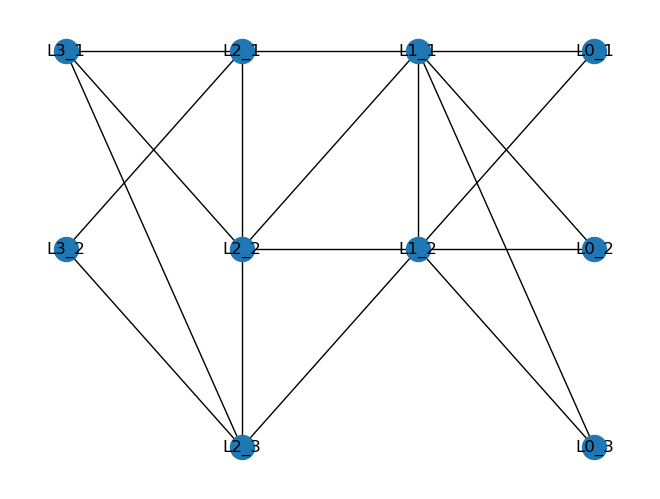

In [219]:

H = G.copy()


for n in H.nodes:
    print(n, H.nodes[n].get("direction"), H.nodes[n].get("puc_value"))
"""
for u, v in H.edges:
    print(u, v, H[u][v]["relation"])


for n in H.nodes:
    print(n, H.nodes[n].get("direction"), H.nodes[n].get("puc_value"))
print("\n")
for u, v in H.edges:
    print(u, v, H[u][v]["relation"])
"""
# Position nodes for plotting
pos = {}
for layer, nodes in layers.items():
    for i, node in enumerate(sorted(nodes)):
        pos[node] = (-layer, -i)
"""

for k in sorted(layers):
    print(f"L_{k}: {layers[k]}")
"""
# Draw graph
nx.draw(H,pos,with_labels=True)
#nx.draw(H)
plt.show()


In [221]:
def get_rid_minority_edges(H, v, d, node_layer, majority):
    for u in list(H.neighbors(v)):
        # consider previous layer (d-1) and same layer (d)
        if node_layer.get(u) not in (d - 1, d):
            continue

        rel = H[u][v].get("relation")
        dir_u = H.nodes[u].get("direction")

        if rel not in (+1, -1) or dir_u not in (+1, -1):
            continue

        vote = dir_u / rel  # +1 or -1

        if vote != majority:
            #H[u][v]["relation"] = 0   # actually modifies the edge
            H.remove_edge(u, v)



In [ ]:
# For each layer
node_layer = {}
for d, nodes in layers.items():
    for n in nodes:
        node_layer[n] = d


for d in sorted(layers.keys()):
    #print(d)
    if d == 0: #Continue from layer 1, ignore layer 0
        continue 
        
    for v in layers[d]:
        
        if not H.has_node(v):
            continue
        pos_votes = 0
        neg_votes = 0
        total = 0
        #print("TOTAL", total)
        print("Node: ",v)

# -----------------------------------------------------
        """
        print("Neighbors of L1_1:", list(H.neighbors("L1_1")))
        print("Prev-layer neighbors of L1_1:", [u for u in H.neighbors("L1_1") if node_layer.get(u) == 0])
        
        for u in ["L0_1","L0_2","L0_3"]:
            if H.has_edge(u, "L1_1"):
                print(u, "relation=", H[u]["L1_1"].get("relation"), "dir=", H.nodes[u].get("direction"))
            else:
                print(u, "edge MISSING to L1_1")
        """
# -----------------------------------------------------

        # Consider only edges from previous layer (d-1) for current node
        for u in H.neighbors(v): # u is each "neighbor" of v in previous layer
            #print("Total:",total)
            if (node_layer.get(u) != d - 1):
                continue
            #print(u)
            rel = H[u][v].get("relation")
            dir_u = H.nodes[u].get("direction")
            
            # only consider edges and nodes that are +1 or -1 (ignores 0's)
            if rel not in (+1, -1) or dir_u not in (+1, -1):
                continue       
            total += 1  # count only valid votes
            #print("Total:",total)
            vote = dir_u / rel
            if vote > 0:
                pos_votes += 1
            else:
                neg_votes += 1


        
        # If no nodes from previous layer, leave it unchanged
        if total == 0:
            continue

        # decide new node direction based on node and calculate puc_value
        # more pos direction votes
        if pos_votes >= neg_votes:
            majority = +1
            puc = neg_votes / total
            #print("pos")
            #print(neg_votes, "/", total, "=",puc)
            H.nodes[v]["direction"] = +1 
            H.nodes[v]["puc_value"] = puc
            #get_rid_minority_edges(H, v, d, node_layer, majority)
          
        # more neg direction votes
        elif neg_votes > pos_votes:
            majority = -1
            #print("neg")
            puc = pos_votes / total
            #print(pos_votes, "/", total, "=",puc)
            #print(puc)
            H.nodes[v]["direction"] = -1
            H.nodes[v]["puc_value"] = puc
            #get_rid_minority_edges(H, v, d, node_layer, majority)

        else:
            # if number of votes for pos = neg
            H.nodes[v]["direction"] = 0
            puc = 0.5
            H.nodes[v]["puc_value"] = puc
            #print("to be deleted")
            majority = 0
            #get_rid_minority_edges(H, v, d, node_layer, 0)
            continue
        
        #print(puc)
        # If puc_value is low, delete nodes
        if puc > 0.4:
            H.remove_node(v)
            continue

        # Get rid of edges accordingly
        get_rid_minority_edges(H, v, d, node_layer, majority)

# ---------------------------------------------------------------------------------------------------------------------


# ---------------------------------------------------------------------------------------------------------------------



# Check (safe even after node deletions)
for d in sorted(layers):
    #print(f"Layer {d}:")
    for n in sorted(layers[d]):
        if not H.has_node(n):
            print(" ", n, "(deleted)")
            continue
        print(" ", n, H.nodes[n].get("direction"), H.nodes[n].get("puc_value"))

print("\nEdges in H after removing:")
for u, v in H.edges:
    print(u, v, H[u][v].get("relation"))

nx.draw(H,pos,with_labels=True)
#nx.draw(H)
plt.show()


17 - 9 = 8

In [1]:
coverts_to_networkx(edge,nodes)
reverse_puc(network, subnetwork1, subnetwork2)
color nodes according to direction
color edges according to sign 


SyntaxError: invalid syntax (2149726363.py, line 3)

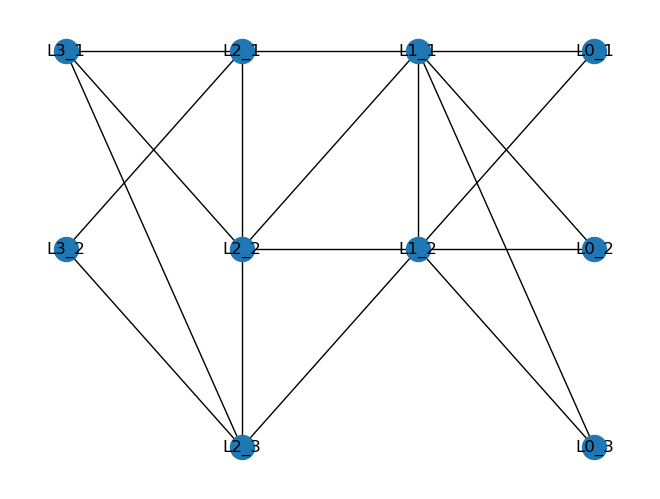

Node:  L1_1
Node:  L1_2
Node:  L2_1
Node:  L2_2
Node:  L2_3
Node:  L3_1
Node:  L3_2
  L0_1 1 1.0
  L0_2 1 1.0
  L0_3 -1 1.0
  L1_1 1 0.3333333333333333
  L1_2 -1 0.3333333333333333
  L2_1 1 0.0
  L2_2 (deleted)
  L2_3 -1 0.0
  L3_1 (deleted)
  L3_2 -1 0.0

Edges in H after removing:
L0_1 L1_1 1
L0_1 L1_2 -1
L0_2 L1_2 -1
L0_3 L1_1 -1
L1_1 L2_1 1
L1_2 L2_3 1
L2_1 L2_3 -1
L2_1 L3_2 -1
L2_3 L3_2 1


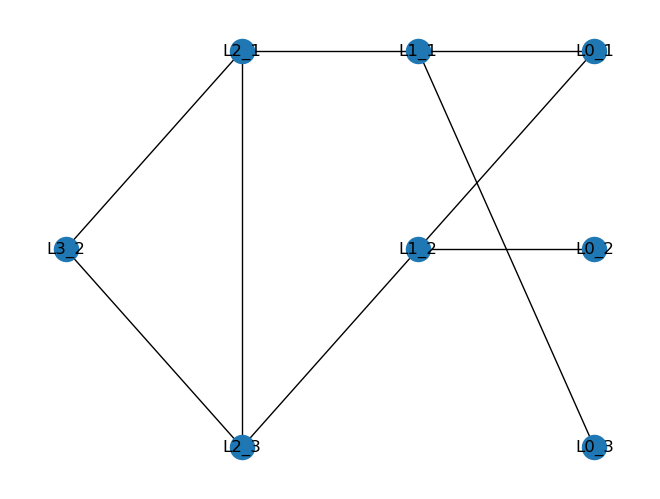

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# Build graph + initial attrs
# ----------------------------
G = nx.Graph()

layers = {
    0: ["L0_1", "L0_2", "L0_3"],
    1: ["L1_1", "L1_2"],
    2: ["L2_1", "L2_2", "L2_3"],
    3: ["L3_1", "L3_2"],
}

direction = {"L0_1": +1, "L0_2": +1, "L0_3": -1}
puc_value = {"L0_1": 1.00, "L0_2": 1.00, "L0_3": 1.00}

G.add_nodes_from(n for nodes in layers.values() for n in nodes)
nx.set_node_attributes(G, direction, "direction")
nx.set_node_attributes(G, puc_value, "puc_value")

cross_edges = {
    ("L0_1", "L1_1"): +1, ("L0_1", "L1_2"): -1,
    ("L0_2", "L1_1"): -1, ("L0_2", "L1_2"): -1,
    ("L0_3", "L1_1"): -1, ("L0_3", "L1_2"): -1,
    ("L1_1", "L1_2"): +1,
    ("L1_1", "L2_1"): +1, ("L1_1", "L2_2"): +1,
    ("L1_2", "L2_2"): +1, ("L1_2", "L2_3"): +1,
    ("L2_1", "L2_3"): -1,
    ("L2_1", "L3_1"): +1, ("L2_1", "L3_2"): -1,
    ("L2_2", "L3_1"): -1,
    ("L2_3", "L3_1"): +1, ("L2_3", "L3_2"): +1,
}
G.add_edges_from((u, v, {"relation": rel}) for (u, v), rel in cross_edges.items())

H = G.copy()

# ----------------------------
# Layout + helper structures
# ----------------------------
pos = {node: (-d, -i) for d, nodes in layers.items() for i, node in enumerate(sorted(nodes))}
node_layer = {n: d for d, nodes in layers.items() for n in nodes}

nx.draw(H, pos, with_labels=True)
plt.show()


def get_rid_minority_edges(H, v, d, node_layer, majority):
    for u in list(H.neighbors(v)):
        if node_layer.get(u) not in (d - 1, d):
            continue
        rel = H[u][v].get("relation")
        dir_u = H.nodes[u].get("direction")
        if rel not in (+1, -1) or dir_u not in (+1, -1):
            continue
        if (dir_u / rel) != majority:
            H.remove_edge(u, v)


# ----------------------------
# Main pass by layers
# ----------------------------
for d in sorted(layers):
    if d == 0:
        continue

    for v in layers[d]:
        if not H.has_node(v):
            continue

        pos_votes = neg_votes = total = 0
        print("Node: ", v)

        for u in H.neighbors(v):
            if node_layer.get(u) != d - 1:
                continue
            rel = H[u][v].get("relation")
            dir_u = H.nodes[u].get("direction")
            if rel not in (+1, -1) or dir_u not in (+1, -1):
                continue

            total += 1
            
            if (dir_u / rel) > 0:
                pos_votes += 1
            else:
                neg_votes += 1


        if total == 0:
            print("yes")
            continue

        if pos_votes >= neg_votes:
            majority = +1
            puc = neg_votes / total
            H.nodes[v]["direction"] = +1
            H.nodes[v]["puc_value"] = puc
        elif neg_votes > pos_votes:
            majority = -1
            puc = pos_votes / total
            H.nodes[v]["direction"] = -1
            H.nodes[v]["puc_value"] = puc
        else:
            H.nodes[v]["direction"] = 0
            H.nodes[v]["puc_value"] = 0.5
            continue

        if puc > 0.4:
            H.remove_node(v)
            continue

        get_rid_minority_edges(H, v, d, node_layer, majority)

# ----------------------------
# Report + draw
# ----------------------------
for d in sorted(layers):
    for n in sorted(layers[d]):
        if not H.has_node(n):
            print(" ", n, "(deleted)")
        else:
            print(" ", n, H.nodes[n].get("direction"), H.nodes[n].get("puc_value"))

print("\nEdges in H after removing:")
for u, v in H.edges:
    print(u, v, H[u][v].get("relation"))

nx.draw(H, pos, with_labels=True)
plt.show()


In [14]:
ls

H_nodes_direction.csv     IGNORE-pls-pls_edges.csv  main.ipynb
IGNORE-pls-cpx_edges.csv  IGNORE-temp.csv           Original.ipynb
